In [ ]:
# ============================================================
# NOTEBOOK 6 — CROSS-DATASET VALIDATION (MedMNIST ChestMNIST)
# Paste Universal Cell 0 first, then each CELL block below
# into a separate Colab cell, in order.
#
# PURPOSE:
#   Evaluate whether representations learned on ChestX6 (6-class)
#   transfer to ChestMNIST (NIH ChestX-ray14, binary classification).
#   NO training on ChestX6 labels during transfer evaluation.
#   Tests: linear probe + fine-tune for top 5 models.
#
# WHY BINARY (not 14-class):
#   ChestMNIST collapses ChestX-ray14 → normal vs any pathology.
#   Label spaces are incompatible for direct transfer (different diseases).
#   Binary task cleanly tests whether ChestX6 features generalise
#   to an independent scanner/population — standard protocol in literature.
# ============================================================

In [1]:
# ── UNIVERSAL CELL 0 ──────────────────────────────────────────────
# It mounts Drive, loads all splits, and builds CONFIG.

from google.colab import drive
import os, json, sys
import pandas as pd

drive.mount('/content/drive', force_remount=False)

BASE = '/content/drive/MyDrive/MedSSL_Research'
assert os.path.exists(BASE), f'Drive folder not found: {BASE}'

# Load master dataframe (created by Notebook 1)
df = pd.read_csv(f'{BASE}/splits/master_dataframe.csv')

# Load official splits — NEVER regenerate these
train_idx = json.load(open(f'{BASE}/splits/train_indices.json'))
val_idx   = json.load(open(f'{BASE}/splits/val_indices.json'))
test_idx  = json.load(open(f'{BASE}/splits/test_indices.json'))
sub10_idx = json.load(open(f'{BASE}/splits/subset_10pct_seed42.json'))
sub20_idx = json.load(open(f'{BASE}/splits/subset_20pct_seed42.json'))

CLASS_NAMES = sorted(df['label_name'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)  # should be 6

# Load helper files from Drive
sys.path.insert(0, BASE)
import importlib.util
def load_from_drive(filename, module_name):
    spec = importlib.util.spec_from_file_location(
        module_name, f'{BASE}/{filename}')
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

aug = load_from_drive('augmentations.py', 'augmentations')
dc  = load_from_drive('dataset_class.py', 'dataset_class')
MedicalImageDataset         = dc.MedicalImageDataset
SUPERVISED_TRAIN_TRANSFORMS = aug.SUPERVISED_TRAIN_TRANSFORMS
SUPERVISED_VAL_TRANSFORMS   = aug.SUPERVISED_VAL_TRANSFORMS
SSL_PRETRAIN_TRANSFORMS     = aug.SSL_PRETRAIN_TRANSFORMS

CONFIG = {
    'base':          BASE,
    'data_dir':      f'{BASE}/dataset/processed',
    'splits_dir':    f'{BASE}/splits',
    'ckpt_dir':      f'{BASE}/checkpoints',
    'results_dir':   f'{BASE}/results',
    'figures_dir':   f'{BASE}/figures',
    'num_classes':   NUM_CLASSES,
    'class_names':   CLASS_NAMES,
    'seed':          42,
    'seeds':         [42, 123, 456],
    'batch_size':    32,
    'epochs':        100,
    'early_stop':    10,
    'lr_backbone':   1e-4,
    'lr_head':       1e-3,
    'weight_decay':  1e-4,
    'use_amp':       True,
    'image_size':    224,
    'subsets': {'10pct': sub10_idx, '20pct': sub20_idx, '100pct': train_idx},
}

os.makedirs(CONFIG['results_dir'], exist_ok=True)
os.makedirs(CONFIG['figures_dir'], exist_ok=True)

print(f'Drive: OK | Classes: {NUM_CLASSES} | ',
      f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

Mounted at /content/drive
Drive: OK | Classes: 6 |  Train: 12591 | Val: 1799 | Test: 3598


### Import All Libraries

In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install                                        ║
# ╚══════════════════════════════════════════════════════════╝

import subprocess, sys

def pip_install(pkgs):
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs,
        capture_output=True
    )

pip_install(['medmnist', 'torch', 'torchvision', 'timm',
             'scikit-learn', 'matplotlib', 'seaborn', 'tqdm',
             'numpy', 'pandas'])

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
import torchvision.transforms as T
import timm
import medmnist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, time, random
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import (f1_score, accuracy_score,
                              roc_auc_score, confusion_matrix)
from tqdm.notebook import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

print(f'MedMNIST version: {medmnist.__version__}')

FIG_DPI  = 300
FIGS_DIR = CONFIG['figures_dir']
RES_DIR  = CONFIG['results_dir']
os.makedirs(FIGS_DIR, exist_ok=True)
os.makedirs(RES_DIR,  exist_ok=True)

# ChestMNIST save directory
CHESTMNIST_DIR = f'{CONFIG["base"]}/dataset/chestmnist'
os.makedirs(CHESTMNIST_DIR, exist_ok=True)

print()
print('=' * 55)
print('  CELL 1 COMPLETE')
print('=' * 55)

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
MedMNIST version: 3.0.2

  CELL 1 COMPLETE


### Zip and Unzip all classes in parallel

In [ ]:
# Run this ONCE to create a zip on Drive
# After this, Cell 2b unzips in ~2 min instead of copying in 2 hours

import os, time, subprocess

DRIVE_DATA = '/content/drive/MyDrive/MedSSL_Research/dataset/processed'
LOCAL_DATA = '/content/chest_data'
ZIP_DIR    = '/content/drive/MyDrive/MedSSL_Research/dataset/class_zips'

os.makedirs(LOCAL_DATA, exist_ok=True)
os.makedirs(ZIP_DIR,    exist_ok=True)

# ── Check if already done this session ───────────────────────
total_local = sum(len(f) for _, _, f in os.walk(LOCAL_DATA))
print(f'Files already on local SSD: {total_local:,}')

if total_local >= len(df) * 0.95:
    print('Already copied this session. Skipping copy.')

else:
    # ── Step 1: Create per-class zips on Drive (ONE TIME ONLY) ─
    # Each class zip is ~400-500MB — unzipping in parallel is fast
    classes_on_drive = [
        c for c in sorted(os.listdir(DRIVE_DATA))
        if os.path.isdir(os.path.join(DRIVE_DATA, c))
    ]
    zips_exist = all(
        os.path.exists(f'{ZIP_DIR}/{c}.zip') for c in classes_on_drive
    )

    if not zips_exist:
        print('Creating per-class zip files on Drive (one-time, ~5-10 min) ...')
        for cls in classes_on_drive:
            zip_path = f'{ZIP_DIR}/{cls}.zip'
            if os.path.exists(zip_path):
                print(f'  Already exists: {cls}.zip')
                continue
            print(f'  Zipping {cls} ...', end=' ', flush=True)
            t0 = time.time()
            os.system(f'cd "{DRIVE_DATA}" && zip -r -q "{zip_path}" "{cls}/"')
            size = os.path.getsize(zip_path) / 1e6
            print(f'{size:.0f} MB  ({time.time()-t0:.0f}s)')
        print('All class zips created. Future sessions will be fast.')
    else:
        print('Class zips already exist on Drive.')

Files already on local SSD: 0
Class zips already exist on Drive.


In [ ]:
 # ── Step 2: Unzip all classes in parallel ─────────────────

print(f'\nUnzipping all classes to local SSD in parallel ...')
t0 = time.time()

procs = []
for cls_zip in sorted(os.listdir(ZIP_DIR)):
    if not cls_zip.endswith('.zip'):
        continue
    zip_path = os.path.join(ZIP_DIR, cls_zip)
    proc = subprocess.Popen(
        ['unzip', '-q', '-o', zip_path, '-d', LOCAL_DATA],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )
    procs.append((cls_zip, proc))
    print(f'  Started: {cls_zip}')

for cls_zip, proc in procs:
    proc.wait()
    print(f'  Done   : {cls_zip}')

elapsed = (time.time() - t0) / 60
total_local = sum(len(f) for _, _, f in os.walk(LOCAL_DATA))
print(f'\nAll unzipped in {elapsed:.1f} min  —  {total_local:,} files')

# ── Fix df paths to point to local SSD ───────────────────────
print('\nUpdating df image_path to local SSD ...')

def fix_path(p):
    """Rebuild path using just class_folder/filename from any prefix."""
    parts = p.replace('\\', '/').split('/')
    # parts[-1] = filename, parts[-2] = class folder
    return os.path.join(LOCAL_DATA, parts[-2], parts[-1])

df['image_path'] = df['image_path'].apply(fix_path)

# ── Verify ────────────────────────────────────────────────────
missing = df['image_path'].apply(lambda p: not os.path.exists(p)).sum()
print(f'Missing files: {missing} / {len(df)}')

if missing == 0:
    print('All paths verified. Ready to train.')
    print(f'Sample: {df["image_path"].iloc[0]}')
else:
    print(f'[WARN] {missing} files missing.')
    print('Check that class folder names in zip match df label_name column.')
    print('df label_name values:', df['label_name'].unique().tolist())
    print('Local SSD folders   :', os.listdir(LOCAL_DATA))

print()
print('=' * 55)
print('  CELL 2b COMPLETE')
print(f'  Local SSD : {LOCAL_DATA}')
print(f'  Files     : {total_local:,}')
print('  Per-session cost: ~2-3 min unzip')
print('=' * 55)



Unzipping all classes to local SSD in parallel ...
  Started: covid-19.zip
  Started: emphysema.zip
  Started: normal.zip
  Started: pneumonia-bacterial.zip
  Started: pneumonia-viral.zip
  Started: tuberculosis.zip
  Done   : covid-19.zip
  Done   : emphysema.zip
  Done   : normal.zip
  Done   : pneumonia-bacterial.zip
  Done   : pneumonia-viral.zip
  Done   : tuberculosis.zip

All unzipped in 0.1 min  —  17,988 files

Updating df image_path to local SSD ...
Missing files: 0 / 17988
All paths verified. Ready to train.
Sample: /content/chest_data/covid-19/train_COVID-3132.jpg

  CELL 2b COMPLETE
  Local SSD : /content/chest_data
  Files     : 17,988
  Per-session cost: ~2-3 min unzip


### Load ChestMNIST Dataset

In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — Load ChestMNIST Dataset                       ║
# ╚══════════════════════════════════════════════════════════╝

from medmnist import ChestMNIST

# ── Transforms ───────────────────────────────────────────────
# ChestMNIST: 28×28 grayscale → resize to 224×224, convert to RGB
# Use ImageNet normalisation (our models expect it)
CHESTMNIST_TRAIN_TRANSFORM = T.Compose([
    T.Resize(256),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.Grayscale(num_output_channels=3),   # grayscale → 3-channel RGB
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

CHESTMNIST_VAL_TRANSFORM = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

print('Downloading / loading ChestMNIST ...')
train_dataset = ChestMNIST(
    split='train', transform=CHESTMNIST_TRAIN_TRANSFORM,
    download=True, root=CHESTMNIST_DIR, size=28
)
val_dataset = ChestMNIST(
    split='val', transform=CHESTMNIST_VAL_TRANSFORM,
    download=True, root=CHESTMNIST_DIR, size=28
)
test_dataset = ChestMNIST(
    split='test', transform=CHESTMNIST_VAL_TRANSFORM,
    download=True, root=CHESTMNIST_DIR, size=28
)

# ChestMNIST has multi-label format — collapse to binary
# Label = 0 if all zeros (Normal), 1 if any pathology
class BinaryChestMNIST(torch.utils.data.Dataset):
    """
    Wraps ChestMNIST and collapses multi-label to binary.

    Original: 14-class multi-label (one-hot)
    Binary  : 0 = Normal (all labels zero)
              1 = Any pathology (at least one label = 1)

    Parameters
    ----------
    base_dataset : medmnist.ChestMNIST
    transform    : callable (already applied by base dataset)
    """
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        img, label = self.base[i]
        # label is shape (14,) — collapse to binary
        binary_label = int(label.max().item() > 0)
        return img, torch.tensor(binary_label, dtype=torch.long)


train_ds = BinaryChestMNIST(train_dataset)
val_ds   = BinaryChestMNIST(val_dataset)
test_ds  = BinaryChestMNIST(test_dataset)

# Class balance check
train_labels = [train_ds[i][1].item() for i in range(min(500, len(train_ds)))]
n_normal   = train_labels.count(0)
n_pathology = train_labels.count(1)
print(f'\nChestMNIST (binary) statistics:')
print(f'  Train : {len(train_ds):,} samples')
print(f'  Val   : {len(val_ds):,} samples')
print(f'  Test  : {len(test_ds):,} samples')
print(f'  Class balance (sample of 500): '
      f'Normal={n_normal} ({n_normal/5:.1f}%), '
      f'Pathology={n_pathology} ({n_pathology/5:.1f}%)')
print(f'  Binary task: Normal (0) vs Any Pathology (1)')

# DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print()
print('=' * 55)
print('  CELL 2 COMPLETE — ChestMNIST loaded')
print('=' * 55)


ChestMNIST (binary) statistics:
  Train : 78,468 samples
  Val   : 11,219 samples
  Test  : 22,433 samples
  Class balance (sample of 500): Normal=273 (54.6%), Pathology=227 (45.4%)
  Binary task: Normal (0) vs Any Pathology (1)

  CELL 2 COMPLETE — ChestMNIST loaded


### Load Top 5 Models from ChestX6 Training

In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — Load Top 5 Models from ChestX6 Training       ║
# ╚══════════════════════════════════════════════════════════╝

def build_encoder(model_name):
    """
    Build model architecture WITHOUT classification head.
    Returns (encoder, feat_dim).

    Parameters
    ----------
    model_name : str

    Returns
    -------
    tuple (nn.Module encoder, int feat_dim)
    """
    if model_name in ('resnet50_pretrained', 'resnet50_scratch'):
        enc = tvm.resnet50(weights=None)
        enc.fc = nn.Identity()
        feat_dim = 2048

    elif model_name == 'efficientnet_b0':
        enc = timm.create_model('efficientnet_b0',
                                pretrained=False, num_classes=0)
        feat_dim = enc.num_features

    elif model_name == 'mobilevit_xs':
        enc = timm.create_model('mobilevit_xs',
                                pretrained=False, num_classes=0)
        feat_dim = enc.num_features

    elif model_name == 'simclr_resnet50':
        backbone = tvm.resnet50(weights=None)
        backbone.fc = nn.Identity()
        enc      = backbone
        feat_dim = 2048

    elif model_name == 'mae_vits16':
        enc = timm.create_model('vit_small_patch16_224',
                                pretrained=False, num_classes=0)
        feat_dim = enc.num_features   # 384

    else:
        raise ValueError(f'Unknown model: {model_name}')

    return enc, feat_dim


def load_encoder_from_chestx6(model_name):
    """
    Load encoder weights from ChestX6 fine-tuned checkpoint.
    Strips the classification head — returns encoder only.

    For SSL models: also accepts the pretraining encoder checkpoint.

    Parameters
    ----------
    model_name : str

    Returns
    -------
    tuple (nn.Module encoder on DEVICE, int feat_dim) or (None, None)
    """
    supervised = ['resnet50_pretrained', 'resnet50_scratch',
                  'efficientnet_b0', 'mobilevit_xs']
    ssl_models = ['simclr_resnet50', 'mae_vits16']

    enc, feat_dim = build_encoder(model_name)

    # Try fine-tuned checkpoint first (best seed=42, 100% labels)
    if model_name in supervised:
        ckpt_path = (f'{CONFIG["ckpt_dir"]}/supervised/'
                     f'{model_name}_100pct_seed42_best.pt')
    else:
        ckpt_path = (f'{CONFIG["ckpt_dir"]}/finetuned/'
                     f'{model_name}_100pct_seed42_best.pt')

    if not os.path.exists(ckpt_path):
        # For SSL models: try pretraining encoder checkpoint
        if model_name == 'simclr_resnet50':
            ckpt_path = f'{CONFIG["ckpt_dir"]}/ssl/simclr_resnet50_encoder_final.pth'
        elif model_name == 'mae_vits16':
            ckpt_path = f'{CONFIG["ckpt_dir"]}/ssl/mae_vits16_encoder_final.pth'

    if not os.path.exists(ckpt_path):
        print(f'  [WARN] No checkpoint found for {model_name}')
        return None, None

    ckpt = torch.load(ckpt_path, map_location='cpu')
    state = ckpt.get('model_state', ckpt.get('encoder_state', ckpt))

    # Strip classification head keys
    enc_state = {}
    for k, v in state.items():
        # Remove common head key patterns
        if any(k.startswith(p) for p in
               ['fc.', 'head.', 'classifier.', '1.']):
            continue
        # Remove sequential wrapper prefix '0.'
        new_k = k[2:] if k.startswith('0.') else k
        enc_state[new_k] = v

    missing, unexpected = enc.load_state_dict(enc_state, strict=False)
    enc = enc.to(DEVICE)
    print(f'  Loaded: {model_name:<28} | '
          f'missing={len(missing)} unexpected={len(unexpected)}')
    return enc, feat_dim


# Top 5 models to evaluate
TOP5_MODELS = [
    'resnet50_pretrained',
    'efficientnet_b0',
    'mobilevit_xs',
    'simclr_resnet50',
    'mae_vits16',
]

MODEL_LABELS = {
    'resnet50_pretrained' : 'ResNet50 (ImageNet)',
    'efficientnet_b0'     : 'EfficientNet-B0',
    'mobilevit_xs'        : 'MobileViT-XS',
    'simclr_resnet50'     : 'SimCLR + ResNet50',
    'mae_vits16'          : 'MAE + ViT-S/16',
}
MODEL_COLORS = {
    'resnet50_pretrained' : '#185FA5',
    'efficientnet_b0'     : '#1D9E75',
    'mobilevit_xs'        : '#534AB7',
    'simclr_resnet50'     : '#D85A30',
    'mae_vits16'          : '#854F0B',
}

print('Loading ChestX6-trained encoders ...')
encoders = {}
feat_dims = {}
for mn in TOP5_MODELS:
    enc, fdim = load_encoder_from_chestx6(mn)
    if enc is not None:
        encoders[mn]   = enc
        feat_dims[mn]  = fdim

print(f'\nLoaded {len(encoders)}/{len(TOP5_MODELS)} encoders')

print()
print('=' * 55)
print('  CELL 3 COMPLETE — encoders loaded')
print('=' * 55)

Loading ChestX6-trained encoders ...
  Loaded: resnet50_pretrained          | missing=0 unexpected=0
  Loaded: efficientnet_b0              | missing=0 unexpected=0
  Loaded: mobilevit_xs                 | missing=0 unexpected=0
  Loaded: simclr_resnet50              | missing=0 unexpected=0
  Loaded: mae_vits16                   | missing=0 unexpected=0

Loaded 5/5 encoders

  CELL 3 COMPLETE — encoders loaded


### Bootstrap CIs, per-class sensitivity/specificity CIs, and binary-collapsed ChestX6 AUC (R3-M5, R3-N2, R3-M3(b))

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

CLASS_NAMES = sorted(df['label_name'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)
NORMAL_IDX  = CLASS_NAMES.index('normal')
print(f'Classes: {CLASS_NAMES}  |  normal index = {NORMAL_IDX}')

def load_full_classifier(model_name, subset_name='100pct', seed=42):
    supervised = ['resnet50_pretrained', 'resnet50_scratch', 'efficientnet_b0', 'mobilevit_xs']
    if model_name in supervised:
        ckpt_path = f'{CONFIG["ckpt_dir"]}/supervised/{model_name}_{subset_name}_seed{seed}_best.pt'
        if model_name in ('resnet50_pretrained', 'resnet50_scratch'):
            full = tvm.resnet50(weights=None); full.fc = nn.Linear(2048, NUM_CLASSES)
        elif model_name == 'efficientnet_b0':
            full = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
        elif model_name == 'mobilevit_xs':
            full = timm.create_model('mobilevit_xs', pretrained=False, num_classes=NUM_CLASSES)
    else:
        ckpt_path = f'{CONFIG["ckpt_dir"]}/finetuned/{model_name}_{subset_name}_seed{seed}_best.pt'
        enc, feat_dim = build_encoder(model_name)
        full = nn.Sequential(enc, nn.Linear(feat_dim, NUM_CLASSES))
    if not os.path.exists(ckpt_path):
        print(f'  [WARN] checkpoint not found: {ckpt_path}'); return None
    ckpt = torch.load(ckpt_path, map_location='cpu')
    full.load_state_dict(ckpt['model_state'])
    return full.to(DEVICE).eval()

def run_inference_chestx6(model, batch_size=64):
    test_ds = MedicalImageDataset(df, test_idx, transform=SUPERVISED_VAL_TRANSFORMS)
    loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    all_labels, all_probs = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            probs = torch.softmax(model(imgs.to(DEVICE)), dim=1)
            all_labels.append(labels.numpy()); all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_labels), np.vstack(all_probs)

# ── Step 1: run inference once per (model, subset) needed ──
MODELS_TO_EVAL = {}
for subset in ['10pct', '20pct', '100pct']:
    for mn in ['resnet50_pretrained', 'resnet50_scratch', 'mobilevit_xs',
               'simclr_resnet50', 'mae_vits16']:
        MODELS_TO_EVAL[(mn, subset)] = f'{MODEL_LABELS.get(mn, mn)} @ {subset}'
MODELS_TO_EVAL[('efficientnet_b0', '100pct')] = 'EfficientNet-B0 @ 100pct'  # for the per-class table only
predictions = {}
for (mn, subset), label in MODELS_TO_EVAL.items():
    print(f'Running inference: {label} ...')
    model = load_full_classifier(mn, subset_name=subset)
    if model is None: continue
    predictions[(mn, subset)] = run_inference_chestx6(model)
    del model
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()
print(f'\nCollected predictions for {len(predictions)} (model, subset) pairs.')

# ── Step 2: R3-N2 — per-class sensitivity/specificity + bootstrap CI ──
def per_class_sens_spec(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    sens, spec = np.zeros(n_classes), np.zeros(n_classes)
    for c in range(n_classes):
        tp = cm[c, c]; fn = cm[c, :].sum() - tp; fp = cm[:, c].sum() - tp; tn = cm.sum() - tp - fn - fp
        sens[c] = tp / (tp + fn + 1e-8); spec[c] = tn / (tn + fp + 1e-8)
    return sens, spec

def bootstrap_sens_spec_ci(y_true, y_prob, n_classes, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed); n = len(y_true); y_pred = y_prob.argmax(axis=1)
    sens_boot = np.zeros((n_boot, n_classes)); spec_boot = np.zeros((n_boot, n_classes))
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        sens_boot[b], spec_boot[b] = per_class_sens_spec(y_true[idx], y_pred[idx], n_classes)
    return np.percentile(sens_boot, [2.5, 97.5], axis=0), np.percentile(spec_boot, [2.5, 97.5], axis=0)

print('\n--- R3-N2: Per-class sensitivity/specificity with 95% bootstrap CIs ---')
sens_spec_rows = []
for (mn, subset), (y_true, y_prob) in predictions.items():
    if subset != '100pct': continue
    sens, spec = per_class_sens_spec(y_true, y_prob.argmax(axis=1), NUM_CLASSES)
    sens_ci, spec_ci = bootstrap_sens_spec_ci(y_true, y_prob, NUM_CLASSES)
    for c, cname in enumerate(CLASS_NAMES):
        sens_spec_rows.append({'Model': MODEL_LABELS.get(mn, mn), 'Class': cname,
            'Sensitivity': round(sens[c],4), 'Sens_CI_lo': round(sens_ci[0,c],4), 'Sens_CI_hi': round(sens_ci[1,c],4),
            'Specificity': round(spec[c],4), 'Spec_CI_lo': round(spec_ci[0,c],4), 'Spec_CI_hi': round(spec_ci[1,c],4)})
sens_spec_df = pd.DataFrame(sens_spec_rows)
sens_spec_df.to_csv(f'{CONFIG["results_dir"]}/per_class_sens_spec_ci.csv', index=False)
print(sens_spec_df)

# ── Step 3: R3-M5 — bootstrap CI on paired F1 differences ──
def bootstrap_paired_f1_diff(y_true_a, y_prob_a, y_true_b, y_prob_b, n_boot=2000, seed=42):
    assert np.array_equal(y_true_a, y_true_b), 'Test sets must match for a paired comparison'
    y_true = y_true_a; n = len(y_true); rng = np.random.RandomState(seed)
    pred_a, pred_b = y_prob_a.argmax(axis=1), y_prob_b.argmax(axis=1)
    diffs = np.zeros(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        diffs[b] = (f1_score(y_true[idx], pred_a[idx], average='macro', zero_division=0)
                   - f1_score(y_true[idx], pred_b[idx], average='macro', zero_division=0))
    f1_a = f1_score(y_true, pred_a, average='macro', zero_division=0)
    f1_b = f1_score(y_true, pred_b, average='macro', zero_division=0)
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return f1_a, f1_b, f1_a - f1_b, lo, hi

print('\n--- R3-M5: Bootstrap CI on key paired F1 differences ---')
pairs_to_test = []
for subset in ['10pct', '20pct', '100pct']:
    pairs_to_test += [
        (('mae_vits16', subset), ('resnet50_pretrained', subset), f'Best SSL (MAE) vs ResNet50-IN @ {subset}'),
        (('simclr_resnet50', subset), ('resnet50_pretrained', subset), f'SimCLR vs ResNet50-IN @ {subset}'),
        (('mae_vits16', subset), ('resnet50_scratch', subset), f'Best SSL (MAE) vs ResNet50-Scratch @ {subset}'),
        (('mobilevit_xs', subset), ('resnet50_pretrained', subset), f'MobileViT vs ResNet50-IN @ {subset}'),
    ]
paired_rows = []
for key_a, key_b, desc in pairs_to_test:
    if key_a not in predictions or key_b not in predictions:
        print(f'  [SKIP] missing predictions for {desc}'); continue
    ya, pa = predictions[key_a]; yb, pb = predictions[key_b]
    f1a, f1b, diff, lo, hi = bootstrap_paired_f1_diff(ya, pa, yb, pb)
    print(f'{desc}: F1_A={f1a:.4f}  F1_B={f1b:.4f}  Diff={diff:+.4f}  95% CI=[{lo:+.4f}, {hi:+.4f}]')
    paired_rows.append({'Comparison': desc, 'F1_A': round(f1a,4), 'F1_B': round(f1b,4),
                         'Diff': round(diff,4), 'CI_lo': round(lo,4), 'CI_hi': round(hi,4)})
pd.DataFrame(paired_rows).to_csv(f'{CONFIG["results_dir"]}/paired_f1_bootstrap_ci.csv', index=False)

# ── Step 4: R3-M3(b) — binary-collapsed ChestX6 AUC ──
def bootstrap_binary_auc_ci(y_true_bin, p_pathology, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed); n = len(y_true_bin); aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true_bin[idx])) < 2: continue
        aucs.append(roc_auc_score(y_true_bin[idx], p_pathology[idx]))
    return float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))

print('\n--- R3-M3(b): Binary-collapsed ChestX6 AUC (Normal vs Any-Pathology) ---')
print('(New source-domain reference for the redesigned gap; compare against the')
print(' existing ChestMNIST FT-AUC values already in Table 5.)\n')
binary_auc_rows = []
for (mn, subset), (y_true, y_prob) in predictions.items():
    if subset != '100pct': continue
    y_bin, p_path = (y_true != NORMAL_IDX).astype(int), 1.0 - y_prob[:, NORMAL_IDX]
    auc = roc_auc_score(y_bin, p_path)
    ci_lo, ci_hi = bootstrap_binary_auc_ci(y_bin, p_path)
    print(f'{MODEL_LABELS.get(mn, mn):<28} binary AUC = {auc:.4f}  95% CI=[{ci_lo:.4f}, {ci_hi:.4f}]')
    binary_auc_rows.append({'Model': MODEL_LABELS.get(mn, mn), 'model_key': mn,
                             'ChestX6_binary_AUC': round(auc,4), 'CI_lo': round(ci_lo,4), 'CI_hi': round(ci_hi,4)})
binary_auc_df = pd.DataFrame(binary_auc_rows)
binary_auc_df.to_csv(f'{CONFIG["results_dir"]}/chestx6_binary_auc.csv', index=False)
binary_auc_df

Classes: ['covid-19', 'emphysema', 'normal', 'pneumonia-bacterial', 'pneumonia-viral', 'tuberculosis']  |  normal index = 2
Running inference: ResNet50 (ImageNet) @ 10pct ...
Running inference: resnet50_scratch @ 10pct ...
Running inference: MobileViT-XS @ 10pct ...
Running inference: SimCLR + ResNet50 @ 10pct ...
Running inference: MAE + ViT-S/16 @ 10pct ...
Running inference: ResNet50 (ImageNet) @ 20pct ...
Running inference: resnet50_scratch @ 20pct ...
Running inference: MobileViT-XS @ 20pct ...
Running inference: SimCLR + ResNet50 @ 20pct ...
Running inference: MAE + ViT-S/16 @ 20pct ...
Running inference: ResNet50 (ImageNet) @ 100pct ...
Running inference: resnet50_scratch @ 100pct ...
Running inference: MobileViT-XS @ 100pct ...
Running inference: SimCLR + ResNet50 @ 100pct ...
Running inference: MAE + ViT-S/16 @ 100pct ...
Running inference: EfficientNet-B0 @ 100pct ...

Collected predictions for 16 (model, subset) pairs.

--- R3-N2: Per-class sensitivity/specificity with 95% b

,Model,model_key,ChestX6_binary_AUC,CI_lo,CI_hi
0,ResNet50 (ImageNet),resnet50_pretrained,0.9983,0.9975,0.9991
1,resnet50_scratch,resnet50_scratch,0.9979,0.9966,0.9988
2,MobileViT-XS,mobilevit_xs,0.9991,0.9987,0.9995
3,SimCLR + ResNet50,simclr_resnet50,0.9985,0.9964,0.9997
4,MAE + ViT-S/16,mae_vits16,0.9903,0.9870,0.9931
5,EfficientNet-B0,efficientnet_b0,0.9993,0.9989,0.9996


### Holm-Bonferroni correction

In [ ]:
import pandas as pd, numpy as np

def holm_bonferroni(p_values):
    n = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.empty(n)
    running_max = 0.0
    for i, idx in enumerate(order):
        adj = (n - i) * p_values[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted

stat_df = pd.read_csv(f'{RES_DIR}/statistical_tests.csv')  # already produced by NB5 Cell 9
stat_df['p_adj_holm'] = holm_bonferroni(stat_df['p_value'].values)
stat_df['Significant_after_correction'] = stat_df['p_adj_holm'] < 0.05
stat_df.to_csv(f'{RES_DIR}/statistical_tests_holm_corrected.csv', index=False)
print(stat_df[['Subset', 'Comparison', 'p_value', 'p_adj_holm', 'Significant_after_correction']])

    Subset                    Comparison  p_value  p_adj_holm  \
0    10pct       Best SSL vs ResNet50-IN     0.25         1.0   
1    10pct         SimCLR vs ResNet50-IN     0.75         1.0   
2    10pct  Best SSL vs ResNet50-Scratch     0.25         1.0   
3    10pct      MobileViT vs ResNet50-IN     0.50         1.0   
4    20pct       Best SSL vs ResNet50-IN     0.25         1.0   
5    20pct         SimCLR vs ResNet50-IN     0.50         1.0   
6    20pct  Best SSL vs ResNet50-Scratch     0.50         1.0   
7    20pct      MobileViT vs ResNet50-IN     0.50         1.0   
8   100pct       Best SSL vs ResNet50-IN     0.25         1.0   
9   100pct         SimCLR vs ResNet50-IN     1.00         1.0   
10  100pct  Best SSL vs ResNet50-Scratch     0.25         1.0   
11  100pct      MobileViT vs ResNet50-IN     0.50         1.0   

    Significant_after_correction  
0                          False  
1                          False  
2                          False  
3             

### Evaluation Utilities

In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — Evaluation Utilities                          ║
# ╚══════════════════════════════════════════════════════════╝

def set_seed(seed):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def evaluate_binary(model, loader, device):
    """
    Evaluate a binary classification model.

    Parameters
    ----------
    model  : nn.Module in eval() mode
    loader : DataLoader
    device : torch.device

    Returns
    -------
    dict with accuracy, f1, auc metrics
    """
    model.eval()
    all_labels = []
    all_preds  = []
    all_probs  = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
            with torch.amp.autocast(device_type=device.type,
                                    enabled=(device.type == 'cuda')):
                logits = model(imgs)
            probs = torch.softmax(logits, dim=1)[:, 1]   # prob of pathology
            preds = logits.argmax(dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    acc = float(accuracy_score(y_true, y_pred))
    f1  = float(f1_score(y_true, y_pred, average='binary', zero_division=0))

    try:
        auc = float(roc_auc_score(y_true, y_prob))
    except Exception:
        auc = float('nan')

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)
    sensitivity = float(tp / (tp + fn + 1e-8))
    specificity = float(tn / (tn + fp + 1e-8))

    return {
        'accuracy'   : round(acc, 4),
        'f1_binary'  : round(f1,  4),
        'auc_roc'    : round(auc, 4),
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4),
        'n_samples'  : len(y_true),
        'n_positive' : int(y_true.sum()),
    }


print('Evaluation utilities defined.')
print()
print('=' * 55)
print('  CELL 4 COMPLETE')
print('=' * 55)

Evaluation utilities defined.

  CELL 4 COMPLETE


### Linear Probe Transfer    

In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — Linear Probe Transfer                         ║
# ╚══════════════════════════════════════════════════════════╝

# LINEAR PROBE:
# - Freeze encoder completely (no gradient updates)
# - Train ONLY a Linear(feat_dim, 2) head on ChestMNIST train set
# - Evaluate on ChestMNIST test set
# - This isolates quality of learned features from fine-tuning effect

LP_CSV = f'{RES_DIR}/chestmnist_linear_probe.csv'
LP_EPOCHS = 50
LP_LR     = 1e-3


def run_linear_probe(model_name, encoder, feat_dim):
    """
    Run linear probe transfer learning.

    Freezes encoder, trains linear head for LP_EPOCHS epochs.
    Saves result JSON. Skip-if-done.

    Parameters
    ----------
    model_name : str
    encoder    : nn.Module (frozen)
    feat_dim   : int

    Returns
    -------
    dict with test metrics
    """
    result_path = f'{RES_DIR}/lp_{model_name}_chestmnist.json'
    if os.path.exists(result_path):
        print(f'  [SKIP] {model_name} linear probe already done')
        with open(result_path) as f:
            return json.load(f)

    print(f'\n  Linear probe: {MODEL_LABELS.get(model_name, model_name)}')
    set_seed(42)

    # Freeze encoder
    for p in encoder.parameters():
        p.requires_grad = False
    encoder.eval()

    # Trainable linear head only
    head      = nn.Linear(feat_dim, 2).to(DEVICE)
    model     = nn.Sequential(encoder, head)
    optimizer = AdamW(head.parameters(), lr=LP_LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=LP_EPOCHS)
    criterion = nn.CrossEntropyLoss()
    scaler    = torch.amp.GradScaler(DEVICE.type,
                                     enabled=(DEVICE.type == 'cuda'))

    best_val_f1  = 0.0
    best_state   = None
    train_losses = []

    for epoch in range(1, LP_EPOCHS + 1):
        head.train()
        epoch_loss = 0.0
        n_batches  = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type=DEVICE.type,
                                    enabled=(DEVICE.type == 'cuda')):
                # Encoder is frozen — run without grad for efficiency
                with torch.no_grad():
                    features = encoder(imgs)
                logits = head(features)
                loss   = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()
            n_batches  += 1

        scheduler.step()
        avg_loss = epoch_loss / max(n_batches, 1)
        train_losses.append(avg_loss)

        val_metrics = evaluate_binary(model, val_loader, DEVICE)
        val_f1      = val_metrics['f1_binary']

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.clone() for k, v
                           in head.state_dict().items()}

        if epoch % 10 == 0:
            print(f'    ep{epoch:3d}/{LP_EPOCHS}  '
                  f'loss={avg_loss:.4f}  val_f1={val_f1:.4f}')

    # Load best head and evaluate on test set
    if best_state:
        head.load_state_dict(best_state)
    test_metrics = evaluate_binary(model, test_loader, DEVICE)

    result = {
        'model_name'   : model_name,
        'method'       : 'linear_probe',
        'dataset'      : 'ChestMNIST',
        'epochs'       : LP_EPOCHS,
        'best_val_f1'  : best_val_f1,
        'test_metrics' : test_metrics,
        'train_losses' : train_losses,
    }
    with open(result_path, 'w') as f:
        json.dump(result, f, indent=2)

    print(f'  [DONE] Test AUC={test_metrics["auc_roc"]:.4f}  '
          f'F1={test_metrics["f1_binary"]:.4f}  '
          f'Acc={test_metrics["accuracy"]:.4f}')

    # Unfreeze encoder for next use
    for p in encoder.parameters():
        p.requires_grad = True

    return result


if os.path.exists(LP_CSV):
    print('Linear probe results already exist. Loading.')
    lp_results_df = pd.read_csv(LP_CSV)
else:
    print('Running linear probe transfer for all 5 models ...')
    print('Encoder frozen — training linear head only.\n')

    lp_results = []
    for mn in TOP5_MODELS:
        if mn not in encoders:
            print(f'  [SKIP] {mn} encoder not loaded')
            continue
        result = run_linear_probe(mn, encoders[mn], feat_dims[mn])
        tm = result['test_metrics']
        lp_results.append({
            'Model'      : MODEL_LABELS.get(mn, mn),
            'Method'     : 'Linear Probe',
            'AUC-ROC'    : tm['auc_roc'],
            'F1 (Binary)': tm['f1_binary'],
            'Accuracy'   : tm['accuracy'],
            'Sensitivity': tm['sensitivity'],
            'Specificity': tm['specificity'],
        })

    lp_results_df = pd.DataFrame(lp_results)
    lp_results_df.to_csv(LP_CSV, index=False)
    print(f'\nSaved: {LP_CSV}')

print('\nLinear Probe Results:')
print(lp_results_df.to_string(index=False))

print()
print('=' * 55)
print('  CELL 5 COMPLETE — linear probe done')
print('=' * 55)

Linear probe results already exist. Loading.

Linear Probe Results:
              Model       Method  AUC-ROC  F1 (Binary)  Accuracy  Sensitivity  Specificity
ResNet50 (ImageNet) Linear Probe   0.7001       0.6604    0.6186       0.7921       0.4658
    EfficientNet-B0 Linear Probe   0.7049       0.6624    0.6200       0.7962       0.4649
       MobileViT-XS Linear Probe   0.6828       0.6454    0.6152       0.7478       0.4984
  SimCLR + ResNet50 Linear Probe   0.7084       0.6651    0.6419       0.7594       0.5384
     MAE + ViT-S/16 Linear Probe   0.6650       0.6489    0.5447       0.8985       0.2331

  CELL 5 COMPLETE — linear probe done


### ChestMNIST 1%, 5% and 10% Training

In [ ]:
import numpy as np, os, json, torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn as nn
from sklearn.metrics import f1_score, roc_auc_score

# ── Step 1: stratified low-label subsets of the ChestMNIST training set ──
raw_labels = train_dataset.labels
binary_labels_all = (raw_labels.max(axis=1) > 0).astype(int)
n_total = len(binary_labels_all)
print(f'ChestMNIST train set: {n_total:,} total images')

LOW_LABEL_FRACTIONS = {'1pct': 0.01, '5pct': 0.05, '10pct': 0.10}
low_label_indices = {}
for name, frac in LOW_LABEL_FRACTIONS.items():
    idx, _ = train_test_split(
        np.arange(n_total), train_size=frac,
        stratify=binary_labels_all, random_state=42,
    )
    low_label_indices[name] = idx
    n_pos = int(binary_labels_all[idx].sum())
    print(f'  {name}: {len(idx):,} images ({n_pos} pathology, {len(idx)-n_pos} normal)')

# ── Step 2: checkpointed, resumable linear-probe training ──
LP_EPOCHS  = 50
LP_LR      = 1e-3
CKPT_EVERY = 10

def get_paths(model_name, subset_name):
    subset_dir = f'{RES_DIR}/low_label_{subset_name}'
    os.makedirs(subset_dir, exist_ok=True)
    return f'{subset_dir}/lp_{model_name}_ckpt.pt', f'{subset_dir}/lp_{model_name}_final.json'

def run_linear_probe_resumable(model_name, encoder, feat_dim, subset_name, indices):
    ckpt_path, final_path = get_paths(model_name, subset_name)

    if os.path.exists(final_path):
        with open(final_path) as f:
            result = json.load(f)
        print(f'  [SKIP] {model_name} @ {subset_name} already complete '
              f'(AUC={result.get("test_auc", "?")})')
        return result

    for p in encoder.parameters():
        p.requires_grad = False
    encoder.eval()

    subset_train_loader = DataLoader(Subset(train_ds, indices), batch_size=BATCH_SIZE,
                                      shuffle=True, num_workers=0, pin_memory=True)

    head      = nn.Linear(feat_dim, 2).to(DEVICE)
    optimizer = AdamW(head.parameters(), lr=LP_LR)
    scheduler = CosineAnnealingLR(optimizer, T_max=LP_EPOCHS)
    criterion = nn.CrossEntropyLoss()

    start_epoch, best_val_f1, best_state = 1, 0.0, None

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        head.load_state_dict(ckpt['head_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        start_epoch = ckpt['epoch'] + 1
        best_val_f1 = ckpt['best_val_f1']
        best_state  = ckpt['best_head_state']
        print(f'  [RESUME] {model_name} @ {subset_name} from epoch {start_epoch}/{LP_EPOCHS} '
              f'(best_val_f1 so far: {best_val_f1:.4f})')
    else:
        set_seed(42)
        print(f'\n  Linear probe ({subset_name}): {MODEL_LABELS.get(model_name, model_name)}')

    model = nn.Sequential(encoder, head)

    for epoch in range(start_epoch, LP_EPOCHS + 1):
        model.train()
        for imgs, labels in subset_train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
        scheduler.step()

        model.eval()
        val_true, val_pred = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                preds = model(imgs.to(DEVICE)).argmax(dim=1).cpu().numpy()
                val_pred.extend(preds)
                val_true.extend(labels.numpy())
        val_f1 = f1_score(val_true, val_pred, average='macro', zero_division=0)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in head.state_dict().items()}

        print(f'    ep{epoch:3d}/{LP_EPOCHS}  val_f1={val_f1:.4f}  best={best_val_f1:.4f}')

        if epoch % CKPT_EVERY == 0 or epoch == LP_EPOCHS:
            torch.save({'epoch': epoch, 'head_state': head.state_dict(),
                        'optimizer_state': optimizer.state_dict(),
                        'scheduler_state': scheduler.state_dict(),
                        'best_val_f1': best_val_f1, 'best_head_state': best_state}, ckpt_path)
            print(f'    [checkpoint saved @ epoch {epoch}]')

    head.load_state_dict(best_state)
    model.eval()
    test_true, test_prob, test_pred = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            logits = model(imgs.to(DEVICE))
            test_prob.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            test_pred.extend(logits.argmax(dim=1).cpu().numpy())
            test_true.extend(labels.numpy())
    test_true, test_prob, test_pred = np.array(test_true), np.array(test_prob), np.array(test_pred)

    auc = roc_auc_score(test_true, test_prob)
    tp = int(((test_pred == 1) & (test_true == 1)).sum())
    fn = int(((test_pred == 0) & (test_true == 1)).sum())
    sensitivity = tp / (tp + fn + 1e-8)

    result = {'model_name': model_name, 'subset': subset_name, 'n_train_images': len(indices),
              'test_auc': float(auc), 'test_sensitivity': float(sensitivity),
              'best_val_f1': float(best_val_f1)}
    with open(final_path, 'w') as f:
        json.dump(result, f, indent=2)
    if os.path.exists(ckpt_path):
        os.remove(ckpt_path)
    return result

# ── Step 3: run all five cross-dataset-tested models, all three budgets ──
# Re-running this cell after a session restart picks up exactly where it left
# off — completed pairs are skipped, a partial one resumes from its checkpoint.
low_label_results = []
for subset_name, indices in low_label_indices.items():
    for model_name in TOP5_MODELS:
        res = run_linear_probe_resumable(model_name, encoders[model_name],
                                          feat_dims[model_name], subset_name, indices)
        low_label_results.append(res)

low_label_df = pd.DataFrame(low_label_results)
low_label_df.to_csv(f'{RES_DIR}/low_label_linear_probe_summary.csv', index=False)
print(f'\nSaved to {RES_DIR}/low_label_linear_probe_summary.csv')
low_label_df

ChestMNIST train set: 78,468 total images
  1pct: 784 images (360 pathology, 424 normal)
  5pct: 3,923 images (1803 pathology, 2120 normal)
  10pct: 7,846 images (3606 pathology, 4240 normal)
  [SKIP] resnet50_pretrained @ 1pct already complete (AUC=0.6367222452595951)
  [SKIP] efficientnet_b0 @ 1pct already complete (AUC=0.667420555380514)
  [SKIP] mobilevit_xs @ 1pct already complete (AUC=0.6261799098573673)
  [SKIP] simclr_resnet50 @ 1pct already complete (AUC=0.6437900487168609)
  [SKIP] mae_vits16 @ 1pct already complete (AUC=0.6463534179853037)
  [SKIP] resnet50_pretrained @ 5pct already complete (AUC=0.6798188384631125)
  [SKIP] efficientnet_b0 @ 5pct already complete (AUC=0.6741166178412694)
  [SKIP] mobilevit_xs @ 5pct already complete (AUC=0.6502154646106051)
  [SKIP] simclr_resnet50 @ 5pct already complete (AUC=0.6825202524044792)
  [SKIP] mae_vits16 @ 5pct already complete (AUC=0.6591532217260407)
  [SKIP] resnet50_pretrained @ 10pct already complete (AUC=0.6888814083932437

,model_name,subset,n_train_images,test_auc,test_sensitivity,best_val_f1
0,resnet50_pretrained,1pct,784,0.636722,0.551261,0.607359
1,efficientnet_b0,1pct,784,0.667421,0.529081,0.625873
2,mobilevit_xs,1pct,784,0.626180,0.495098,0.584217
3,simclr_resnet50,1pct,784,0.643790,0.532508,0.610240
4,mae_vits16,1pct,784,0.646353,0.544503,0.612212
5,resnet50_pretrained,5pct,3923,0.679819,0.583151,0.635289
6,efficientnet_b0,5pct,3923,0.674117,0.625607,0.636192
7,mobilevit_xs,5pct,3923,0.650215,0.516421,0.614113
8,simclr_resnet50,5pct,3923,0.682520,0.590766,0.636549
9,mae_vits16,5pct,3923,0.659153,0.575155,0.621501


### Fine-Tune Transfer

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — Fine-Tune Transfer                             ║
# ╚══════════════════════════════════════════════════════════╝

# FINE-TUNE TRANSFER:
# - Replace classification head with Linear(feat_dim, 2)
# - Fine-tune ENTIRE model on ChestMNIST train set
# - Same protocol as NB2: differential LR, early stop, AdamW
# - Evaluate on ChestMNIST test set

FT_CSV    = f'{RES_DIR}/chestmnist_finetune.csv'
FT_EPOCHS = 30   # ChestMNIST is smaller, converges faster


def run_finetune_transfer(model_name, encoder, feat_dim):
    """
    Run fine-tune transfer learning on ChestMNIST.

    Full model fine-tuning with differential learning rates.
    Skip-if-done.

    Parameters
    ----------
    model_name : str
    encoder    : nn.Module
    feat_dim   : int

    Returns
    -------
    dict with test metrics
    """
    result_path = f'{RES_DIR}/ft_{model_name}_chestmnist.json'
    if os.path.exists(result_path):
        print(f'  [SKIP] {model_name} fine-tune transfer already done')
        with open(result_path) as f:
            return json.load(f)

    print(f'\n  Fine-tune: {MODEL_LABELS.get(model_name, model_name)}')
    set_seed(42)

    # Unfreeze all encoder parameters
    for p in encoder.parameters():
        p.requires_grad = True

    head  = nn.Linear(feat_dim, 2).to(DEVICE)
    model = nn.Sequential(encoder, head)

    # Differential LR: backbone lower, head higher
    optimizer = AdamW([
        {'params': encoder.parameters(), 'lr': 1e-5},
        {'params': head.parameters(),    'lr': 1e-3},
    ], weight_decay=1e-4)
    scheduler  = CosineAnnealingLR(optimizer, T_max=FT_EPOCHS)
    criterion  = nn.CrossEntropyLoss()
    scaler     = torch.amp.GradScaler(DEVICE.type,
                                      enabled=(DEVICE.type == 'cuda'))

    best_val_f1  = 0.0
    best_state   = None
    patience     = 0
    PATIENCE_MAX = 8
    train_losses = []

    for epoch in range(1, FT_EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        n_batches  = 0

        bar = tqdm(train_loader,
                   desc=f'  ft ep{epoch}/{FT_EPOCHS}',
                   leave=False, mininterval=5.0)
        for imgs, labels in bar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast(device_type=DEVICE.type,
                                    enabled=(DEVICE.type == 'cuda')):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()
            n_batches  += 1
            bar.set_postfix(loss=f'{loss.item():.3f}')

        scheduler.step()
        avg_loss = epoch_loss / max(n_batches, 1)
        train_losses.append(avg_loss)

        val_metrics = evaluate_binary(model, val_loader, DEVICE)
        val_f1      = val_metrics['f1_binary']

        print(f'  ep{epoch:3d}/{FT_EPOCHS}  '
              f'loss={avg_loss:.4f}  '
              f'val_f1={val_f1:.4f}  '
              f'val_auc={val_metrics["auc_roc"]:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience    = 0
            best_state  = {k: v.clone() for k, v
                           in model.state_dict().items()}
        else:
            patience += 1

        if patience >= PATIENCE_MAX:
            print(f'  Early stop at epoch {epoch}')
            break

    # Load best state and evaluate on test
    if best_state:
        model.load_state_dict(best_state)
    test_metrics = evaluate_binary(model, test_loader, DEVICE)

    result = {
        'model_name'   : model_name,
        'method'       : 'fine_tune',
        'dataset'      : 'ChestMNIST',
        'epochs_run'   : epoch,
        'best_val_f1'  : best_val_f1,
        'test_metrics' : test_metrics,
        'train_losses' : train_losses,
    }
    with open(result_path, 'w') as f:
        json.dump(result, f, indent=2)

    print(f'  [DONE] Test AUC={test_metrics["auc_roc"]:.4f}  '
          f'F1={test_metrics["f1_binary"]:.4f}  '
          f'Acc={test_metrics["accuracy"]:.4f}')

    torch.cuda.empty_cache()
    return result


if os.path.exists(FT_CSV):
    print('Fine-tune results already exist. Loading.')
    ft_results_df = pd.read_csv(FT_CSV)
else:
    print('Running fine-tune transfer for all 5 models ...')
    print('Full model fine-tuning on ChestMNIST.\n')

    ft_results = []
    for mn in TOP5_MODELS:
        if mn not in encoders:
            print(f'  [SKIP] {mn} encoder not loaded')
            continue
        result = run_finetune_transfer(mn, encoders[mn], feat_dims[mn])
        tm = result['test_metrics']
        ft_results.append({
            'Model'      : MODEL_LABELS.get(mn, mn),
            'Method'     : 'Fine-Tune',
            'AUC-ROC'    : tm['auc_roc'],
            'F1 (Binary)': tm['f1_binary'],
            'Accuracy'   : tm['accuracy'],
            'Sensitivity': tm['sensitivity'],
            'Specificity': tm['specificity'],
        })

    ft_results_df = pd.DataFrame(ft_results)
    ft_results_df.to_csv(FT_CSV, index=False)
    print(f'\nSaved: {FT_CSV}')

print('\nFine-Tune Transfer Results:')
print(ft_results_df.to_string(index=False))

print()
print('=' * 55)
print('  CELL 6 COMPLETE — fine-tune transfer done')
print('=' * 55)

### Combined Results Table

In [7]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — Combined Results Table                        ║
# ╚══════════════════════════════════════════════════════════╝

print('Building combined results table ...')

SUMMARY_CSV = f'{RES_DIR}/chestmnist_summary.csv'

# Combine linear probe and fine-tune results
combined_rows = []

for mn in TOP5_MODELS:
    label = MODEL_LABELS.get(mn, mn)

    # Load linear probe result
    lp_path = f'{RES_DIR}/lp_{mn}_chestmnist.json'
    lp_auc  = lp_f1 = 'N/A'
    if os.path.exists(lp_path):
        with open(lp_path) as f:
            lp = json.load(f)
        lp_auc = f'{lp["test_metrics"]["auc_roc"]:.4f}'
        lp_f1  = f'{lp["test_metrics"]["f1_binary"]:.4f}'

    # Load fine-tune result
    ft_path = f'{RES_DIR}/ft_{mn}_chestmnist.json'
    ft_auc  = ft_f1 = 'N/A'
    if os.path.exists(ft_path):
        with open(ft_path) as f:
            ft = json.load(f)
        ft_auc = f'{ft["test_metrics"]["auc_roc"]:.4f}'
        ft_f1  = f'{ft["test_metrics"]["f1_binary"]:.4f}'

    combined_rows.append({
        'Model'          : label,
        'LP AUC-ROC'     : lp_auc,
        'LP F1'          : lp_f1,
        'FT AUC-ROC'     : ft_auc,
        'FT F1'          : ft_f1,
    })

combined_df = pd.DataFrame(combined_rows)
combined_df.to_csv(SUMMARY_CSV, index=False)

print('\nTable 4 — Cross-Dataset Transfer (ChestX6 → ChestMNIST):')
print(combined_df.to_string(index=False))
print(f'\nSaved: {SUMMARY_CSV}')

# LaTeX version
print('\nLaTeX for Table 4:')
print(r'\begin{table}[ht]')
print(r'\centering')
print(r'\caption{Cross-dataset transfer: models trained on ChestX6 (6-class)')
print(r'evaluated on ChestMNIST (binary: normal vs.\ any pathology).')
print(r'LP = linear probe (frozen encoder). FT = full fine-tuning.}')
print(r'\label{tab:cross_dataset}')
print(r'\begin{tabular}{lcccc}')
print(r'\toprule')
print(r'Model & LP AUC & LP F1 & FT AUC & FT F1 \\')
print(r'\midrule')
for _, row in combined_df.iterrows():
    print(f'{row["Model"]} & {row["LP AUC-ROC"]} & {row["LP F1"]} '
          f'& {row["FT AUC-ROC"]} & {row["FT F1"]} \\\\')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\end{table}')

print()
print('=' * 55)
print('  CELL 7 COMPLETE — combined table saved')
print('=' * 55)

Building combined results table ...

Table 4 — Cross-Dataset Transfer (ChestX6 → ChestMNIST):
              Model LP AUC-ROC  LP F1 FT AUC-ROC  FT F1
ResNet50 (ImageNet)     0.7001 0.6604     0.7469 0.5995
    EfficientNet-B0     0.7049 0.6624     0.7285 0.6041
       MobileViT-XS     0.6828 0.6454     0.7269 0.5873
  SimCLR + ResNet50     0.7084 0.6651     0.7454 0.5738
     MAE + ViT-S/16     0.6650 0.6489     0.7075 0.6256

Saved: /content/drive/MyDrive/MedSSL_Research/results/chestmnist_summary.csv

LaTeX for Table 4:
\begin{table}[ht]
\centering
\caption{Cross-dataset transfer: models trained on ChestX6 (6-class)
evaluated on ChestMNIST (binary: normal vs.\ any pathology).
LP = linear probe (frozen encoder). FT = full fine-tuning.}
\label{tab:cross_dataset}
\begin{tabular}{lcccc}
\toprule
Model & LP AUC & LP F1 & FT AUC & FT F1 \\
\midrule
ResNet50 (ImageNet) & 0.7001 & 0.6604 & 0.7469 & 0.5995 \\
EfficientNet-B0 & 0.7049 & 0.6624 & 0.7285 & 0.6041 \\
MobileViT-XS & 0.6828 & 0.645

### Transfer Visualisation Figure

Figure: Cross-dataset transfer performance ...


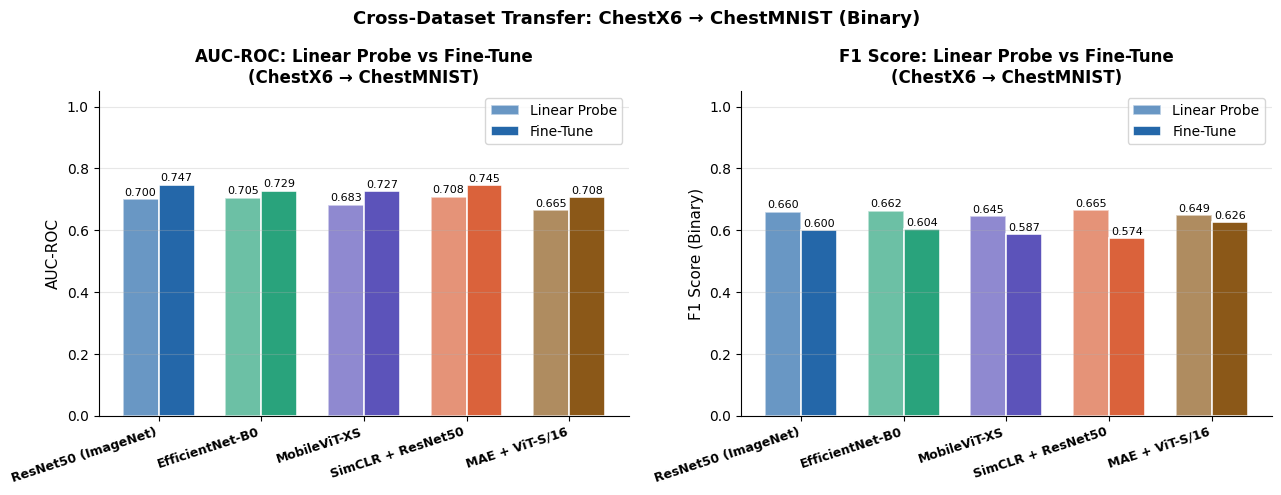

Saved PNG: /content/drive/MyDrive/MedSSL_Research/figures/fig_cross_dataset_transfer.png
Saved PDF: /content/drive/MyDrive/MedSSL_Research/figures/fig_cross_dataset_transfer.pdf

Linear Probe Gap Analysis (LP vs FT — how much fine-tuning helps):
A SMALL gap means the encoder features are rich (good for SSL claims)
A LARGE gap means the features need fine-tuning to be useful

  ResNet50 (ImageNet)          LP=0.7001  FT=0.7469  gap=+0.0468
  EfficientNet-B0              LP=0.7049  FT=0.7285  gap=+0.0236
  MobileViT-XS                 LP=0.6828  FT=0.7269  gap=+0.0441
  SimCLR + ResNet50            LP=0.7084  FT=0.7454  gap=+0.0370
  MAE + ViT-S/16               LP=0.6650  FT=0.7075  gap=+0.0425

  CELL 8 COMPLETE — transfer figure saved


In [14]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — Transfer Visualisation Figure                 ║
# ╚══════════════════════════════════════════════════════════╝

print('Figure: Cross-dataset transfer performance ...')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_present = [mn for mn in TOP5_MODELS if mn in encoders]
labels         = [MODEL_LABELS[mn] for mn in models_present]
colors         = [MODEL_COLORS[mn] for mn in models_present]
x              = np.arange(len(models_present))
width          = 0.35

# ── Left: AUC-ROC comparison ──────────────────────────────────
lp_aucs, ft_aucs = [], []
for mn in models_present:
    lp_path = f'{RES_DIR}/lp_{mn}_chestmnist.json'
    ft_path = f'{RES_DIR}/ft_{mn}_chestmnist.json'
    lp_auc = json.load(open(lp_path))['test_metrics']['auc_roc'] \
        if os.path.exists(lp_path) else 0
    ft_auc = json.load(open(ft_path))['test_metrics']['auc_roc'] \
        if os.path.exists(ft_path) else 0
    lp_aucs.append(lp_auc)
    ft_aucs.append(ft_auc)

ax = axes[0]
bars1 = ax.bar(x - width/2, lp_aucs, width, label='Linear Probe',
               color=colors, alpha=0.65, edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, ft_aucs, width, label='Fine-Tune',
               color=colors, alpha=0.95, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars1, lp_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, ft_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=18, ha='right', fontsize=9, fontweight = "bold")
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('AUC-ROC: Linear Probe vs Fine-Tune\n(ChestX6 → ChestMNIST)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Right: F1 comparison ──────────────────────────────────────
lp_f1s, ft_f1s = [], []
for mn in models_present:
    lp_path = f'{RES_DIR}/lp_{mn}_chestmnist.json'
    ft_path = f'{RES_DIR}/ft_{mn}_chestmnist.json'
    lp_f1 = json.load(open(lp_path))['test_metrics']['f1_binary'] \
        if os.path.exists(lp_path) else 0
    ft_f1 = json.load(open(ft_path))['test_metrics']['f1_binary'] \
        if os.path.exists(ft_path) else 0
    lp_f1s.append(lp_f1)
    ft_f1s.append(ft_f1)

ax = axes[1]
bars1 = ax.bar(x - width/2, lp_f1s, width, label='Linear Probe',
               color=colors, alpha=0.65, edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, ft_f1s, width, label='Fine-Tune',
               color=colors, alpha=0.95, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars1, lp_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, ft_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=18, ha='right', fontsize=9, fontweight = "bold")
ax.set_ylabel('F1 Score (Binary)', fontsize=11)
ax.set_title('F1 Score: Linear Probe vs Fine-Tune\n(ChestX6 → ChestMNIST)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Cross-Dataset Transfer: ChestX6 → ChestMNIST (Binary)',
             fontsize=13, fontweight='bold')
plt.tight_layout()

# ── Save transfer figure in PNG and PDF formats ───────────────
path_transfer_png = f'{FIGS_DIR}/fig_cross_dataset_transfer.png'
path_transfer_pdf = f'{FIGS_DIR}/fig_cross_dataset_transfer.pdf'

# High-resolution PNG — exactly the same figure/settings
plt.savefig(
    path_transfer_png,
    dpi=300,
    bbox_inches='tight'
)

# Publication-quality PDF — same figure, dimensions, fonts, layout,
# and styling; PDF is vector-based, so DPI does not affect its quality
plt.savefig(
    path_transfer_pdf,
    bbox_inches='tight'
)

plt.show()

print(f'Saved PNG: {path_transfer_png}')
print(f'Saved PDF: {path_transfer_pdf}')

# ── LP gap analysis — key paper insight ──────────────────────
print('\nLinear Probe Gap Analysis (LP vs FT — how much fine-tuning helps):')
print('A SMALL gap means the encoder features are rich (good for SSL claims)')
print('A LARGE gap means the features need fine-tuning to be useful\n')
for mn in models_present:
    lp_path = f'{RES_DIR}/lp_{mn}_chestmnist.json'
    ft_path = f'{RES_DIR}/ft_{mn}_chestmnist.json'
    if os.path.exists(lp_path) and os.path.exists(ft_path):
        lp_auc = json.load(open(lp_path))['test_metrics']['auc_roc']
        ft_auc = json.load(open(ft_path))['test_metrics']['auc_roc']
        gap    = ft_auc - lp_auc
        label  = MODEL_LABELS[mn]
        print(f'  {label:<28} LP={lp_auc:.4f}  FT={ft_auc:.4f}  '
              f'gap={gap:+.4f}')

print()
print('=' * 55)
print('  CELL 8 COMPLETE — transfer figure saved')
print('=' * 55)

### Status Summary

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Status Summary                                ║
# ╚══════════════════════════════════════════════════════════╝

def fstat(path):
    return 'OK' if os.path.exists(path) else 'MISSING'

W = 52
print('=' * (W + 10))
print('  NOTEBOOK 7 — STATUS SUMMARY')
print('=' * (W + 10))

files = {
    'chestmnist_linear_probe.csv'        : LP_CSV,
    'chestmnist_finetune.csv'            : FT_CSV,
    'chestmnist_summary.csv'             : SUMMARY_CSV,
    'fig_cross_dataset_transfer.png'     : path_transfer,
}

for name, path in files.items():
    print(f'  {name:<{W}} {fstat(path)}')

# Print Table 4 content for paper
print()
print('  TABLE 4 CONTENT (paste into paper):')
print(f'  {"Model":<28} {"LP AUC":>8} {"LP F1":>8} {"FT AUC":>8} {"FT F1":>8}')
print(f'  {"-"*28} {"-"*8} {"-"*8} {"-"*8} {"-"*8}')
for mn in models_present:
    lp_path = f'{RES_DIR}/lp_{mn}_chestmnist.json'
    ft_path = f'{RES_DIR}/ft_{mn}_chestmnist.json'
    lp_auc = lp_f1 = ft_auc = ft_f1 = 'N/A'
    if os.path.exists(lp_path):
        d = json.load(open(lp_path))['test_metrics']
        lp_auc = f'{d["auc_roc"]:.4f}'
        lp_f1  = f'{d["f1_binary"]:.4f}'
    if os.path.exists(ft_path):
        d = json.load(open(ft_path))['test_metrics']
        ft_auc = f'{d["auc_roc"]:.4f}'
        ft_f1  = f'{d["f1_binary"]:.4f}'
    label = MODEL_LABELS.get(mn, mn)
    print(f'  {label:<28} {lp_auc:>8} {lp_f1:>8} {ft_auc:>8} {ft_f1:>8}')

missing = [p for p in files.values() if not os.path.exists(p)]
status  = 'COMPLETE — READY FOR PAPER SECTION 4.6' \
          if not missing else f'INCOMPLETE — {len(missing)} files missing'
print()
print(f'  STATUS: {status}')
print('=' * (W + 10))

In [ ]:
# It's a library management system with books + DVDs and members who donate and borrow items

# => Core systems
# Manage items
# Manage members
# Borrowing systems

# => Classes
# Items - Books & DVDs (child classes)
# Members
# Collection
# System classes

# => Tasks to do
# Make complete system
# Design GUI interface using JavaFX GUI
# Write JUnit test for your code

# => Tools needed
# Java JDK
# NetBeans
# JUnit

# => Concepts
# Oop
# File handling
# Arraylist and collections
# Basic logic

# => Submission
# Complete java project
# JUnit test
# Exported as zip file